# Problem 3: DIY Dataset Analysis

Dataset Source: https://www.kaggle.com/datasets/shivamb/netflix-shows


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diy_dataset.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (8807, 12)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [27]:
df.info()
print('\nMissing values per column:')
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in     

## Cleaning 1: Handle Missing Values

In [28]:
missing_counts = df.isna().sum()
print('Missing value counts per column:')
print(missing_counts[missing_counts > 0])

# Issue EXISTS in this dataset
cols_to_check = ['director', 'country', 'cast']
missing_rows = df[df[cols_to_check].isna().any(axis=1)]
print(f'\nTotal rows with missing values in director/country/cast: {len(missing_rows)}')
print('\nRows BEFORE cleaning (showing row indices):')
print(missing_rows[['show_id', 'title', 'director', 'country', 'cast']].head(10).to_string())

# Apply fix
df['director'] = df['director'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['rating']   = df['rating'].fillna('Not Rated')
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

print('\nSame rows AFTER cleaning (same indices):')
print(df.loc[missing_rows.index[:10], ['show_id', 'title', 'director', 'country', 'cast']].to_string())

Missing value counts per column:
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64

Total rows with missing values in director/country/cast: 3471

Rows BEFORE cleaning (showing row indices):
   show_id                                title                       director        country                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  cast
0       s1                 Dick Johnson Is Dead                Kirsten Johnson  United States           

## Cleaning 2: Remove Duplicates

In [29]:
dups = df[df.duplicated()]
print(f'Number of duplicate rows found in real dataset: {len(dups)}')

# Issue does NOT exist — demonstrate with a made-up 8-row example
print('\nNo duplicates in real dataset. Demonstrating with a made-up 8-row example:')

example_dups = pd.DataFrame({
    'show_id':      ['s1', 's2', 's3', 's3', 's4', 's5', 's5', 's6'],
    'title':        ['Inception', 'The Crown', 'Narcos', 'Narcos', 'Stranger Things', 'Squid Game', 'Squid Game', 'Ozark'],
    'type':         ['Movie', 'TV Show', 'TV Show', 'TV Show', 'TV Show', 'TV Show', 'TV Show', 'TV Show'],
    'release_year': [2010, 2016, 2015, 2015, 2016, 2021, 2021, 2017]
})

print('\nBEFORE removing duplicates:')
print(example_dups.to_string())

dup_mask = example_dups.duplicated()
print(f'\nDuplicate rows found (row indices: {list(example_dups[dup_mask].index)}):')
print(example_dups[dup_mask].to_string())

example_dups_cleaned = example_dups.drop_duplicates().reset_index(drop=True)
print('\nAFTER removing duplicates:')
print(example_dups_cleaned.to_string())

# Apply to real dataset (no change expected)
df = df.drop_duplicates()
print(f'\nReal dataset shape after drop_duplicates: {df.shape}')

Number of duplicate rows found in real dataset: 0

No duplicates in real dataset. Demonstrating with a made-up 8-row example:

BEFORE removing duplicates:
  show_id            title     type  release_year
0      s1        Inception    Movie          2010
1      s2        The Crown  TV Show          2016
2      s3           Narcos  TV Show          2015
3      s3           Narcos  TV Show          2015
4      s4  Stranger Things  TV Show          2016
5      s5       Squid Game  TV Show          2021
6      s5       Squid Game  TV Show          2021
7      s6            Ozark  TV Show          2017

Duplicate rows found (row indices: [3, 6]):
  show_id       title     type  release_year
3      s3      Narcos  TV Show          2015
6      s5  Squid Game  TV Show          2021

AFTER removing duplicates:
  show_id            title     type  release_year
0      s1        Inception    Movie          2010
1      s2        The Crown  TV Show          2016
2      s3           Narcos  TV Show  

## Cleaning 3: Handle Invalid Values

In [30]:
invalid = df[df['release_year'] < 1888]
print(f'Rows with release_year < 1888 in real dataset: {len(invalid)}')

# Issue does NOT exist — demonstrate with a made-up 7-row example
print('\nNo invalid release years in real dataset. Demonstrating with a made-up 7-row example:')

example_invalid = pd.DataFrame({
    'show_id':      ['s1', 's2', 's3', 's4', 's5', 's6', 's7'],
    'title':        ['Old Movie', 'Good Film', 'Classic', 'Typo Film', 'Another', 'Great Show', 'Bad Entry'],
    'release_year': [1995, 2003, 1750, 2018, 0, 2015, -1]
})

print('\nBEFORE cleaning:')
print(example_invalid.to_string())

invalid_mask = example_invalid['release_year'] < 1888
print(f'\nInvalid rows (row indices: {list(example_invalid[invalid_mask].index)}):')
print(example_invalid[invalid_mask].to_string())

example_invalid_cleaned = example_invalid[~invalid_mask].reset_index(drop=True)
print('\nAFTER removing invalid rows:')
print(example_invalid_cleaned.to_string())

# Apply to real dataset
df = df[df['release_year'] >= 1888].copy()
print(f'\nReal dataset shape after invalid value removal: {df.shape}')

Rows with release_year < 1888 in real dataset: 0

No invalid release years in real dataset. Demonstrating with a made-up 7-row example:

BEFORE cleaning:
  show_id       title  release_year
0      s1   Old Movie          1995
1      s2   Good Film          2003
2      s3     Classic          1750
3      s4   Typo Film          2018
4      s5     Another             0
5      s6  Great Show          2015
6      s7   Bad Entry            -1

Invalid rows (row indices: [2, 4, 6]):
  show_id      title  release_year
2      s3    Classic          1750
4      s5    Another             0
6      s7  Bad Entry            -1

AFTER removing invalid rows:
  show_id       title  release_year
0      s1   Old Movie          1995
1      s2   Good Film          2003
2      s4   Typo Film          2018
3      s6  Great Show          2015

Real dataset shape after invalid value removal: (8807, 12)


## Cleaning 4: Standardize Text

In [31]:
# First check whether the issue exists in this real dataset
text_cols = ['type', 'listed_in', 'country', 'rating']
preview = df[text_cols].copy()
clean_preview = preview.copy()
clean_preview['type'] = clean_preview['type'].astype(str).str.strip().str.title()
clean_preview['listed_in'] = clean_preview['listed_in'].astype(str).str.strip().str.title()
clean_preview['country'] = clean_preview['country'].astype(str).str.strip().str.title()
clean_preview['rating'] = clean_preview['rating'].astype(str).str.strip().str.upper()

changed_mask = (preview != clean_preview).any(axis=1)
changed_rows_before = preview.loc[changed_mask, text_cols]

print(f'Rows needing text standardization in real dataset: {changed_mask.sum()}')
if changed_mask.sum() > 0:
    print('\nChanged rows BEFORE cleaning (showing row indices):')
    print(changed_rows_before.head(10).to_string())

# Apply cleaning only after confirming issue exists
df['type'] = df['type'].astype(str).str.strip().str.title()
df['listed_in'] = df['listed_in'].astype(str).str.strip().str.title()
df['country'] = df['country'].astype(str).str.strip().str.title()
df['rating'] = df['rating'].astype(str).str.strip().str.upper()

if changed_mask.sum() > 0:
    print('\nSame changed rows AFTER cleaning (same indices):')
    print(df.loc[changed_rows_before.index[:10], text_cols].to_string())

Sample of affected columns BEFORE cleaning:
      type                                                      listed_in                                                                country rating
0    Movie                                                  Documentaries                                                          United States  PG-13
1  TV Show                International TV Shows, TV Dramas, TV Mysteries                                                           South Africa  TV-MA
2  TV Show  Crime TV Shows, International TV Shows, TV Action & Adventure                                                                Unknown  TV-MA
3  TV Show                                         Docuseries, Reality TV                                                                Unknown  TV-MA
4  TV Show         International TV Shows, Romantic TV Shows, TV Comedies                                                                  India  TV-MA
5  TV Show                             TV Dr

## Cleaning 5: Normalize Dates

In [32]:
print('Checking whether date format normalization is needed...')
print('Sample of date_added BEFORE cleaning:')
print(df[['date_added']].head(10).to_string())

# Normalize: parse to datetime then reformat
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['date_added'] = df['date_added'].dt.strftime('%Y-%m-%d')

print('\nSample of date_added AFTER cleaning (10 rows):')
print(df[['date_added']].head(10).to_string())

# Save cleaned dataset
df.to_csv('diy_dataset.csv', index=False)
print(f'\nCleaned dataset saved as diy_dataset.csv — final shape: {df.shape}')

Sample of date_added BEFORE cleaning:
           date_added
0  September 25, 2021
1  September 24, 2021
2  September 24, 2021
3  September 24, 2021
4  September 24, 2021
5  September 24, 2021
6  September 24, 2021
7  September 24, 2021
8  September 24, 2021
9  September 24, 2021

Sample of date_added AFTER cleaning (10 rows):
   date_added
0  2021-09-25
1  2021-09-24
2  2021-09-24
3  2021-09-24
4  2021-09-24
5  2021-09-24
6  2021-09-24
7  2021-09-24
8  2021-09-24
9  2021-09-24

Cleaned dataset saved as diy_dataset.csv — final shape: (8807, 12)


In [10]:
df.to_csv("diy_dataset.csv", index=False)

## Preprocessing Summary

### Issues present in the real dataset
- **Missing values** were present (for example in `director`, `country`, and `cast`) and were imputed using appropriate fill values such as `"Unknown"`.
- **Text-format inconsistencies** were present and were standardized (trimmed whitespace, normalized case in selected text columns).
- **Date-format inconsistency** in `date_added` was handled by parsing and converting to uniform `YYYY-MM-DD` format.

### Issues not present in the real dataset
- **Duplicate rows** were checked and not found in the real dataset.
- **Invalid release years** (for example `< 1888`) were checked and not found in the real dataset.

### Made-up examples used to demonstrate required cleaning functions
- Duplicate-row example: repeated title rows were created to show duplicate detection and removal.
- Invalid-value example: impossible years such as `1750`, `0`, and `-1` were created to show invalid-value filtering.

This separation documents which issues were truly observed in the real data versus demonstrated with synthetic examples, matching the assignment requirement.

## Analysis 1: Top-N Within Groups

In [38]:
grouped = (
    df[df['country'] != 'Unknown']
    .groupby(['type', 'country'])
    .size()
    .reset_index(name='title_count')
)

top3 = (
    grouped
    .groupby('type', group_keys=False)
    .apply(lambda x: x.nlargest(3, 'title_count'), include_groups=False)
    .reset_index(drop=True)
)

print('For each content type, top 3 countries by number of titles (N=3):')
print(top3.to_string(index=False))

For each content type, top 3 countries by number of titles (N=3):
       country  title_count
 United States         2058
         India          893
United Kingdom          206
 United States          760
United Kingdom          213
         Japan          169


## Analysis 2: Bin Comparison (Release Year vs Duration Minutes)

In [35]:
# Use two numeric columns directly: release_year and parsed duration_minutes
bin_df = df[['release_year', 'duration']].copy()
bin_df['duration_minutes'] = (
    bin_df['duration']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)
bin_df['duration_minutes'] = pd.to_numeric(bin_df['duration_minutes'], errors='coerce')
bin_df = bin_df.dropna(subset=['release_year', 'duration_minutes'])

bin_df['year_bin'] = pd.cut(
    bin_df['release_year'],
    bins=[1900, 1999, 2013, 2030],
    labels=['Older (<=1999)', 'Mid-Era (2000-2013)', 'Recent (2014+)']
)

bin_result = (
    bin_df
    .groupby('year_bin', observed=True)['duration_minutes']
    .agg(['count', 'mean'])
    .reset_index()
)
bin_result.columns = ['Era Bin', 'Title Count', 'Avg Duration (Minutes)']
bin_result['Avg Duration (Minutes)'] = bin_result['Avg Duration (Minutes)'].round(2)

print('Bin comparison using release_year bins and average duration_minutes:')
print(bin_result.to_string(index=False))

Average number of titles per year, grouped into 3 release-era bins:
            Era Bin  Avg Titles Per Year
   Older (pre-2000)                 2.30
Mid-Era (2000-2013)                 7.12
     Recent (2014+)               267.38


## Analysis 3: Conditional Aggregation (Movies Only)

In [36]:
movies_only = df[df['type'] == 'Movie']

avg_year_by_rating = (
    movies_only
    .groupby('rating')['release_year']
    .mean()
    .reset_index()
)
avg_year_by_rating.columns = ['Rating', 'Avg Release Year']
avg_year_by_rating['Avg Release Year'] = avg_year_by_rating['Avg Release Year'].round(1)
avg_year_by_rating = avg_year_by_rating.sort_values('Avg Release Year', ascending=False)

print("Filter applied: type == 'Movie'")
print('Average release year for each rating (Movies only):')
print(avg_year_by_rating.to_string(index=False))


Filter applied: type == 'Movie'
Average release year for each rating (Movies only):
   Rating  Avg Release Year
     TV-Y            2017.3
   74 MIN            2017.0
     TV-G            2016.4
NOT RATED            2016.0
    TV-MA            2016.0
    TV-Y7            2015.6
   66 MIN            2015.0
    NC-17            2015.0
 TV-Y7-FV            2015.0
    TV-14            2012.6
    TV-PG            2012.5
       NR            2010.9
        R            2010.5
   84 MIN            2010.0
    PG-13            2009.3
       PG            2008.4
       UR            1999.3
        G            1997.8


## Analysis 4: Change Over Time

In [37]:
df['date_added_dt'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_month']    = df['date_added_dt'].dt.to_period('M')

monthly_avg = (
    df.groupby('year_month')['release_year']
    .mean()
    .reset_index()
)
monthly_avg.columns = ['Month', 'Avg Release Year']
monthly_avg['Avg Release Year'] = monthly_avg['Avg Release Year'].round(2)

print('Average release year of titles added to Netflix, grouped by month (most recent 24 months shown):')
print(monthly_avg.tail(24).to_string(index=False))

Average release year of titles added to Netflix, grouped by month (most recent 24 months shown):
  Month  Avg Release Year
2019-10           2012.92
2019-11           2008.94
2019-12           2009.81
2020-01           2010.30
2020-02           2017.75
2020-03           2018.26
2020-04           2015.04
2020-05           2014.60
2020-06           2013.70
2020-07           2016.38
2020-08           2017.09
2020-09           2016.33
2020-10           2015.38
2020-11           2014.89
2020-12           2017.08
2021-01           2013.63
2021-02           2017.34
2021-03           2018.12
2021-04           2016.48
2021-05           2016.61
2021-06           2015.51
2021-07           2015.11
2021-08           2014.30
2021-09           2011.99


# Visualizations

## Visualization 1: Scatter Plot

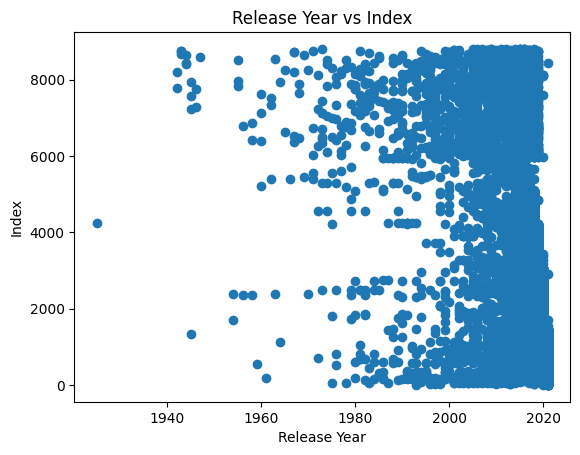

In [14]:
plt.scatter(df['release_year'], df.index)
plt.title("Release Year vs Index")
plt.xlabel("Release Year")
plt.ylabel("Index")
plt.show()

This scatter plot shows how titles are distributed across release years.

## Visualization 2: Histogram

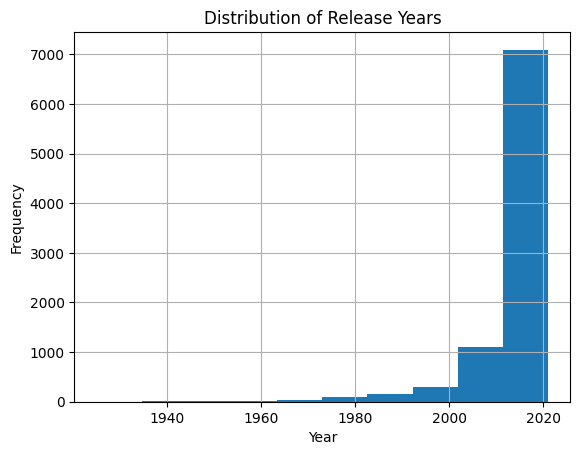

In [15]:
df['release_year'].hist()
plt.title("Distribution of Release Years")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

Most content has been released in recent years.

## Visualization 3: Line Chart

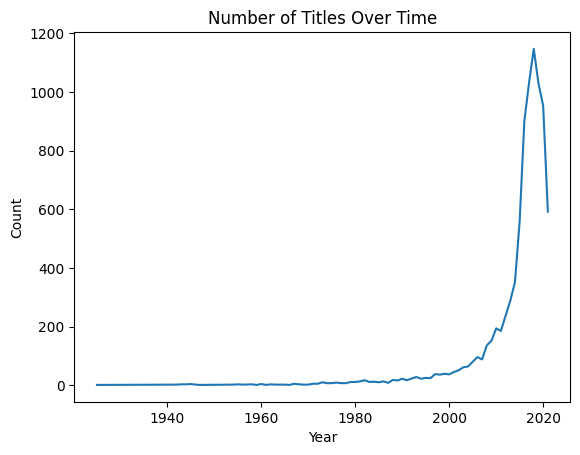

In [16]:
df.groupby('release_year').size().plot()
plt.title("Number of Titles Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

Content production has increased over time.

## Visualization 4: Pie Chart

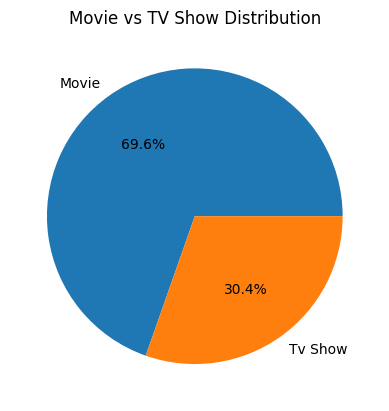

In [17]:
df['type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Movie vs TV Show Distribution")
plt.ylabel("")
plt.show()

Movies make up a larger portion of the dataset compared to TV shows.

## Visualization 5: Box Plot

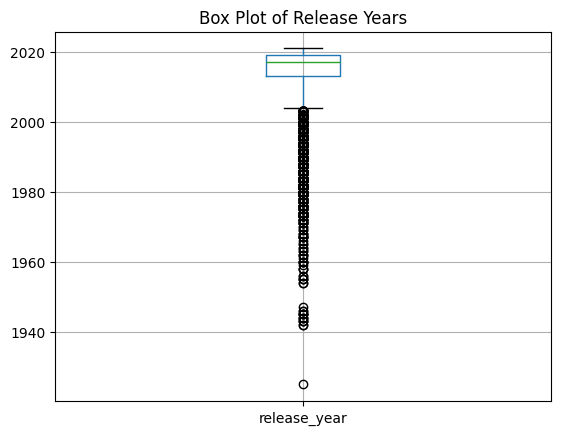

In [18]:
df.boxplot(column='release_year')
plt.title("Box Plot of Release Years")
plt.ylabel("Release Year")
plt.show()

The distribution shows most release years are clustered in recent decades.

In [39]:
df.to_csv('diy_dataset.csv', index=False)